In [3]:
!nvidia-smi

Fri Aug 14 05:09:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             30W /   70W |     293MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [10]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


In [11]:
from ultralytics import YOLO

from IPython.display import display, Image

In [21]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow==1.1.48 --quiet

import roboflow

roboflow.login()

rf = roboflow.Roboflow()

project = rf.workspace("ssnowqueen91-gmail-com").project("license-plate-detecction")
dataset = project.version(1).download("yolov8")

/content/datasets
You are already logged into Roboflow. To make a different login,run roboflow.login(force=True).
loading Roboflow workspace...
loading Roboflow project...

Version export complete for yolov8 format



Extracting Dataset Version Zip to License-Plate-Detecction-1 in yolov8:: 100%|██████████| 52/52 [00:00<00:00, 6578.51it/s]


## Custom Training

In [22]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

/content
100% 21.5M/21.5M [00:00<00:00, 59.7MB/s]
New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/License-Plate-Detecction-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agno

/content


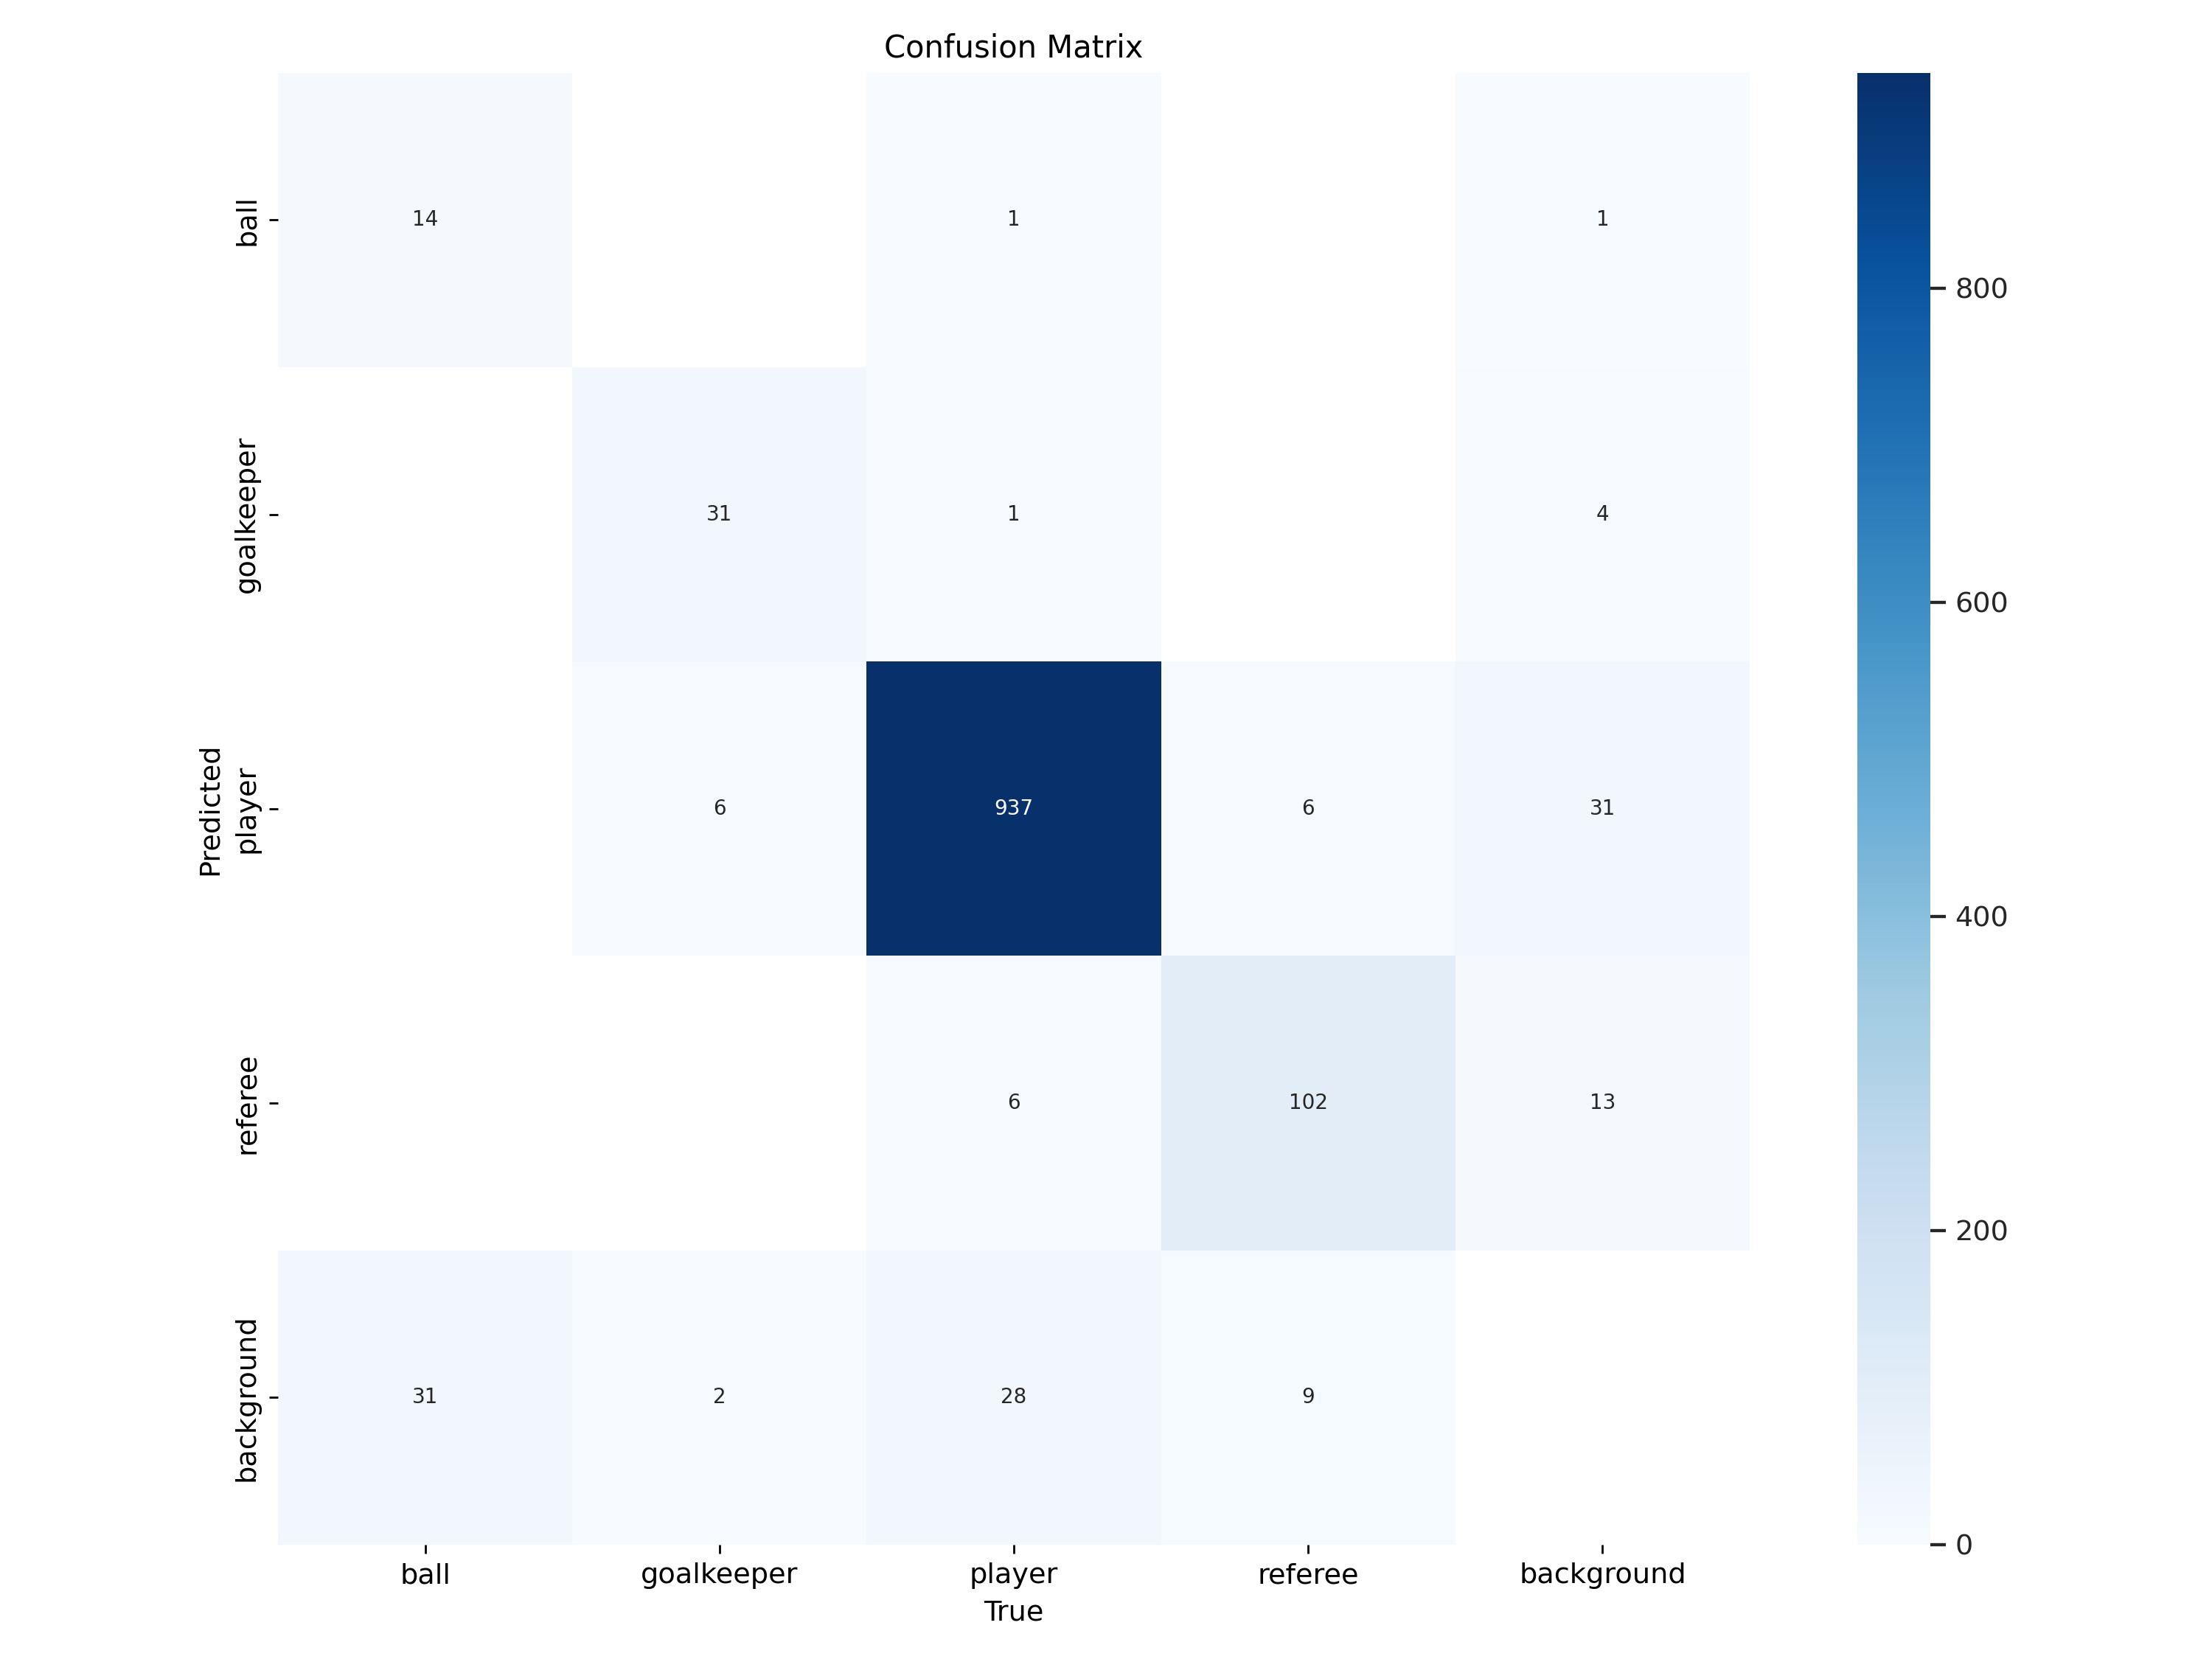

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


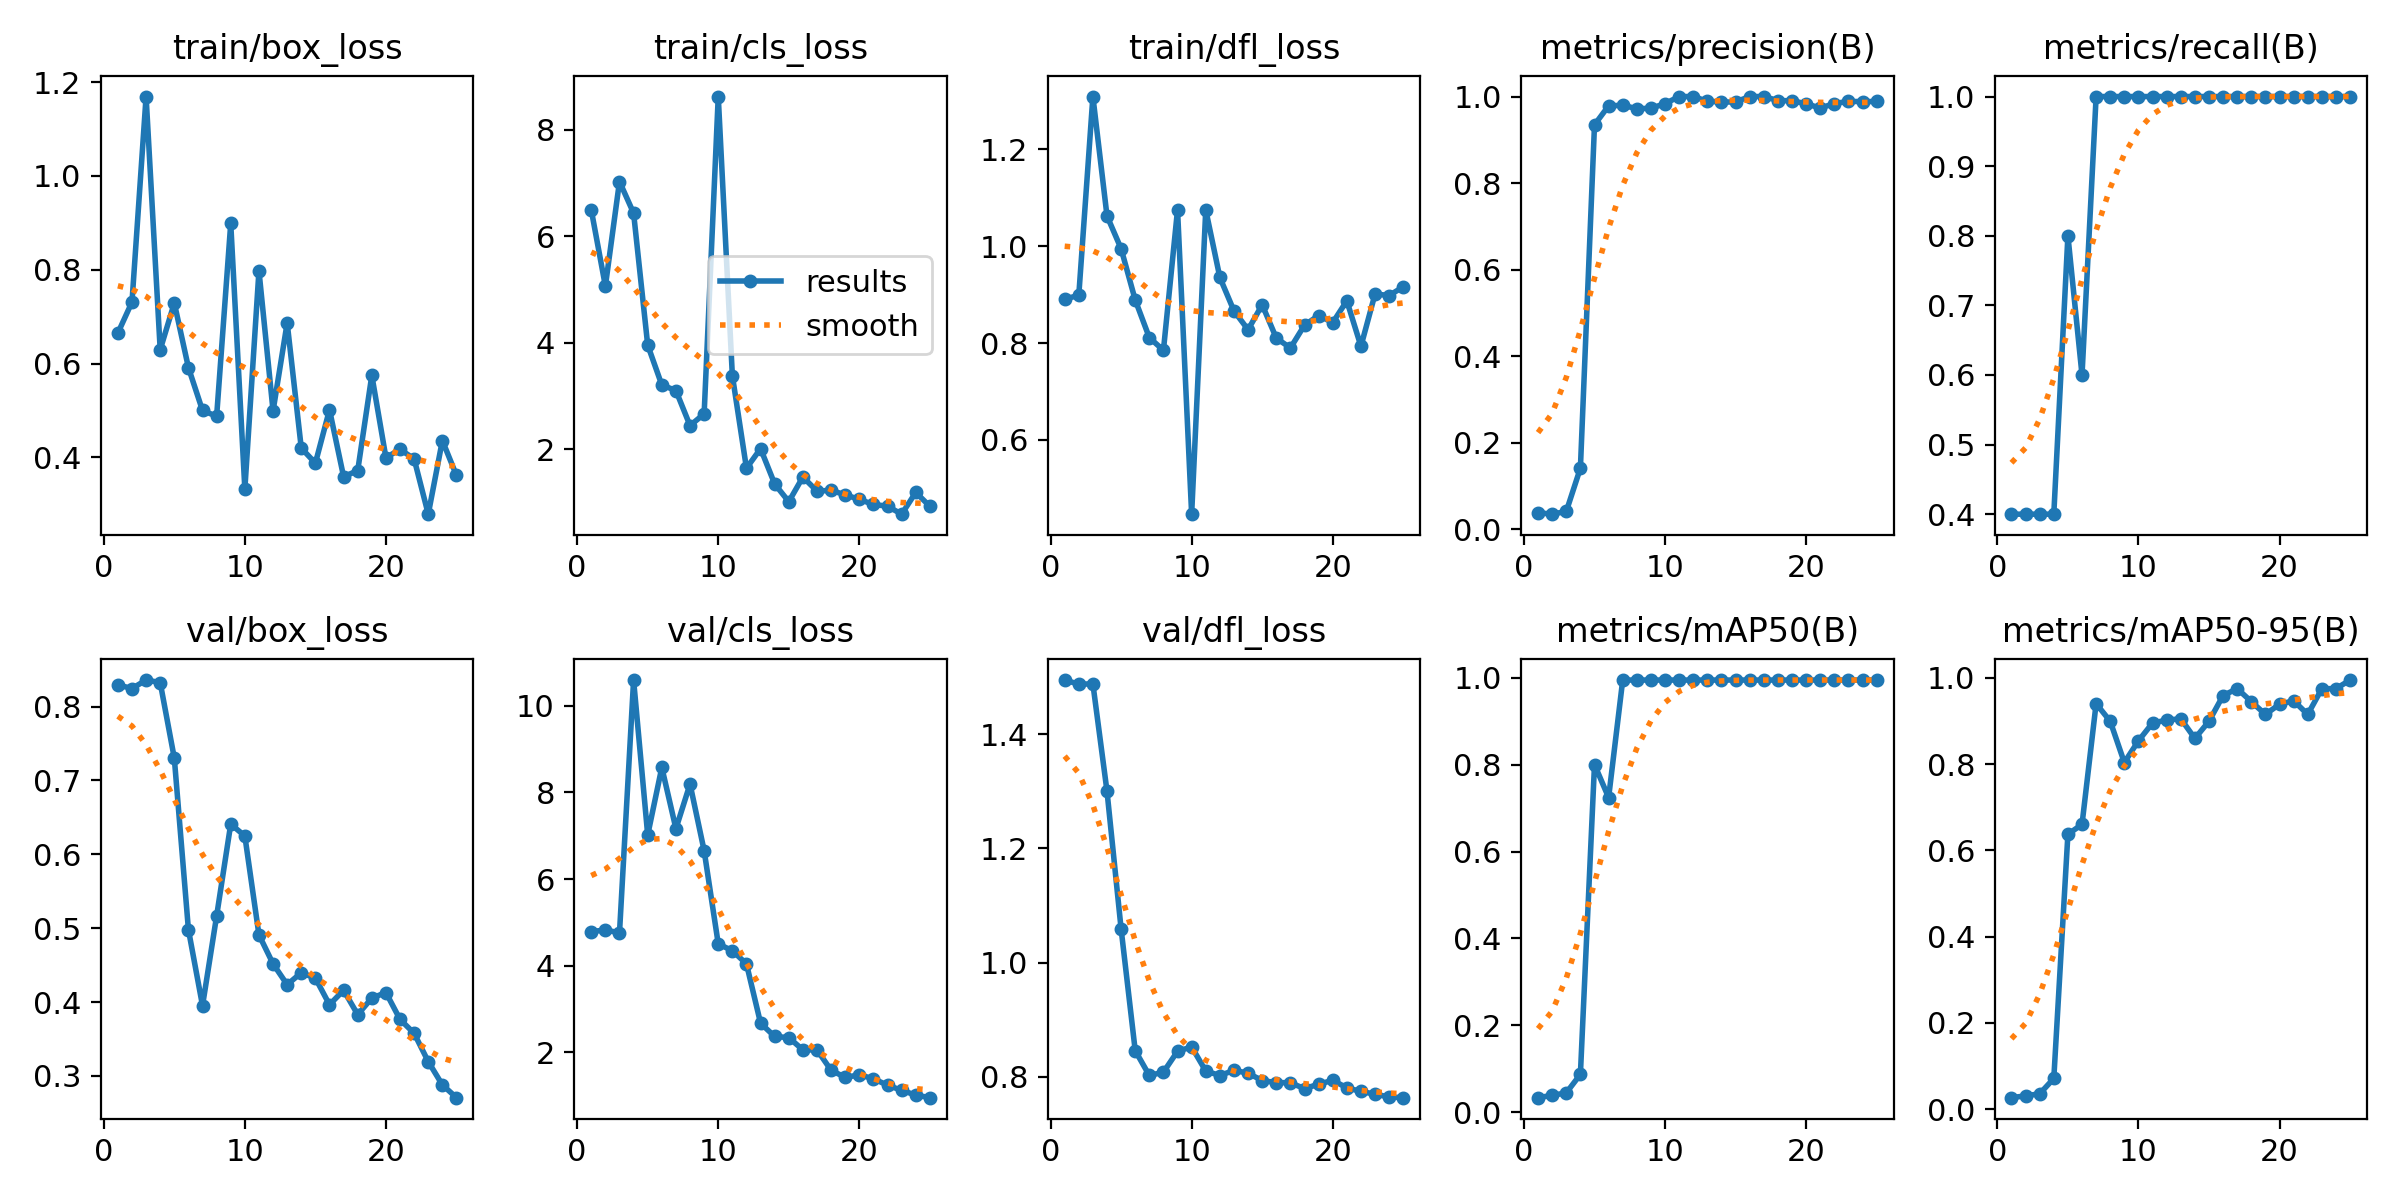

In [23]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


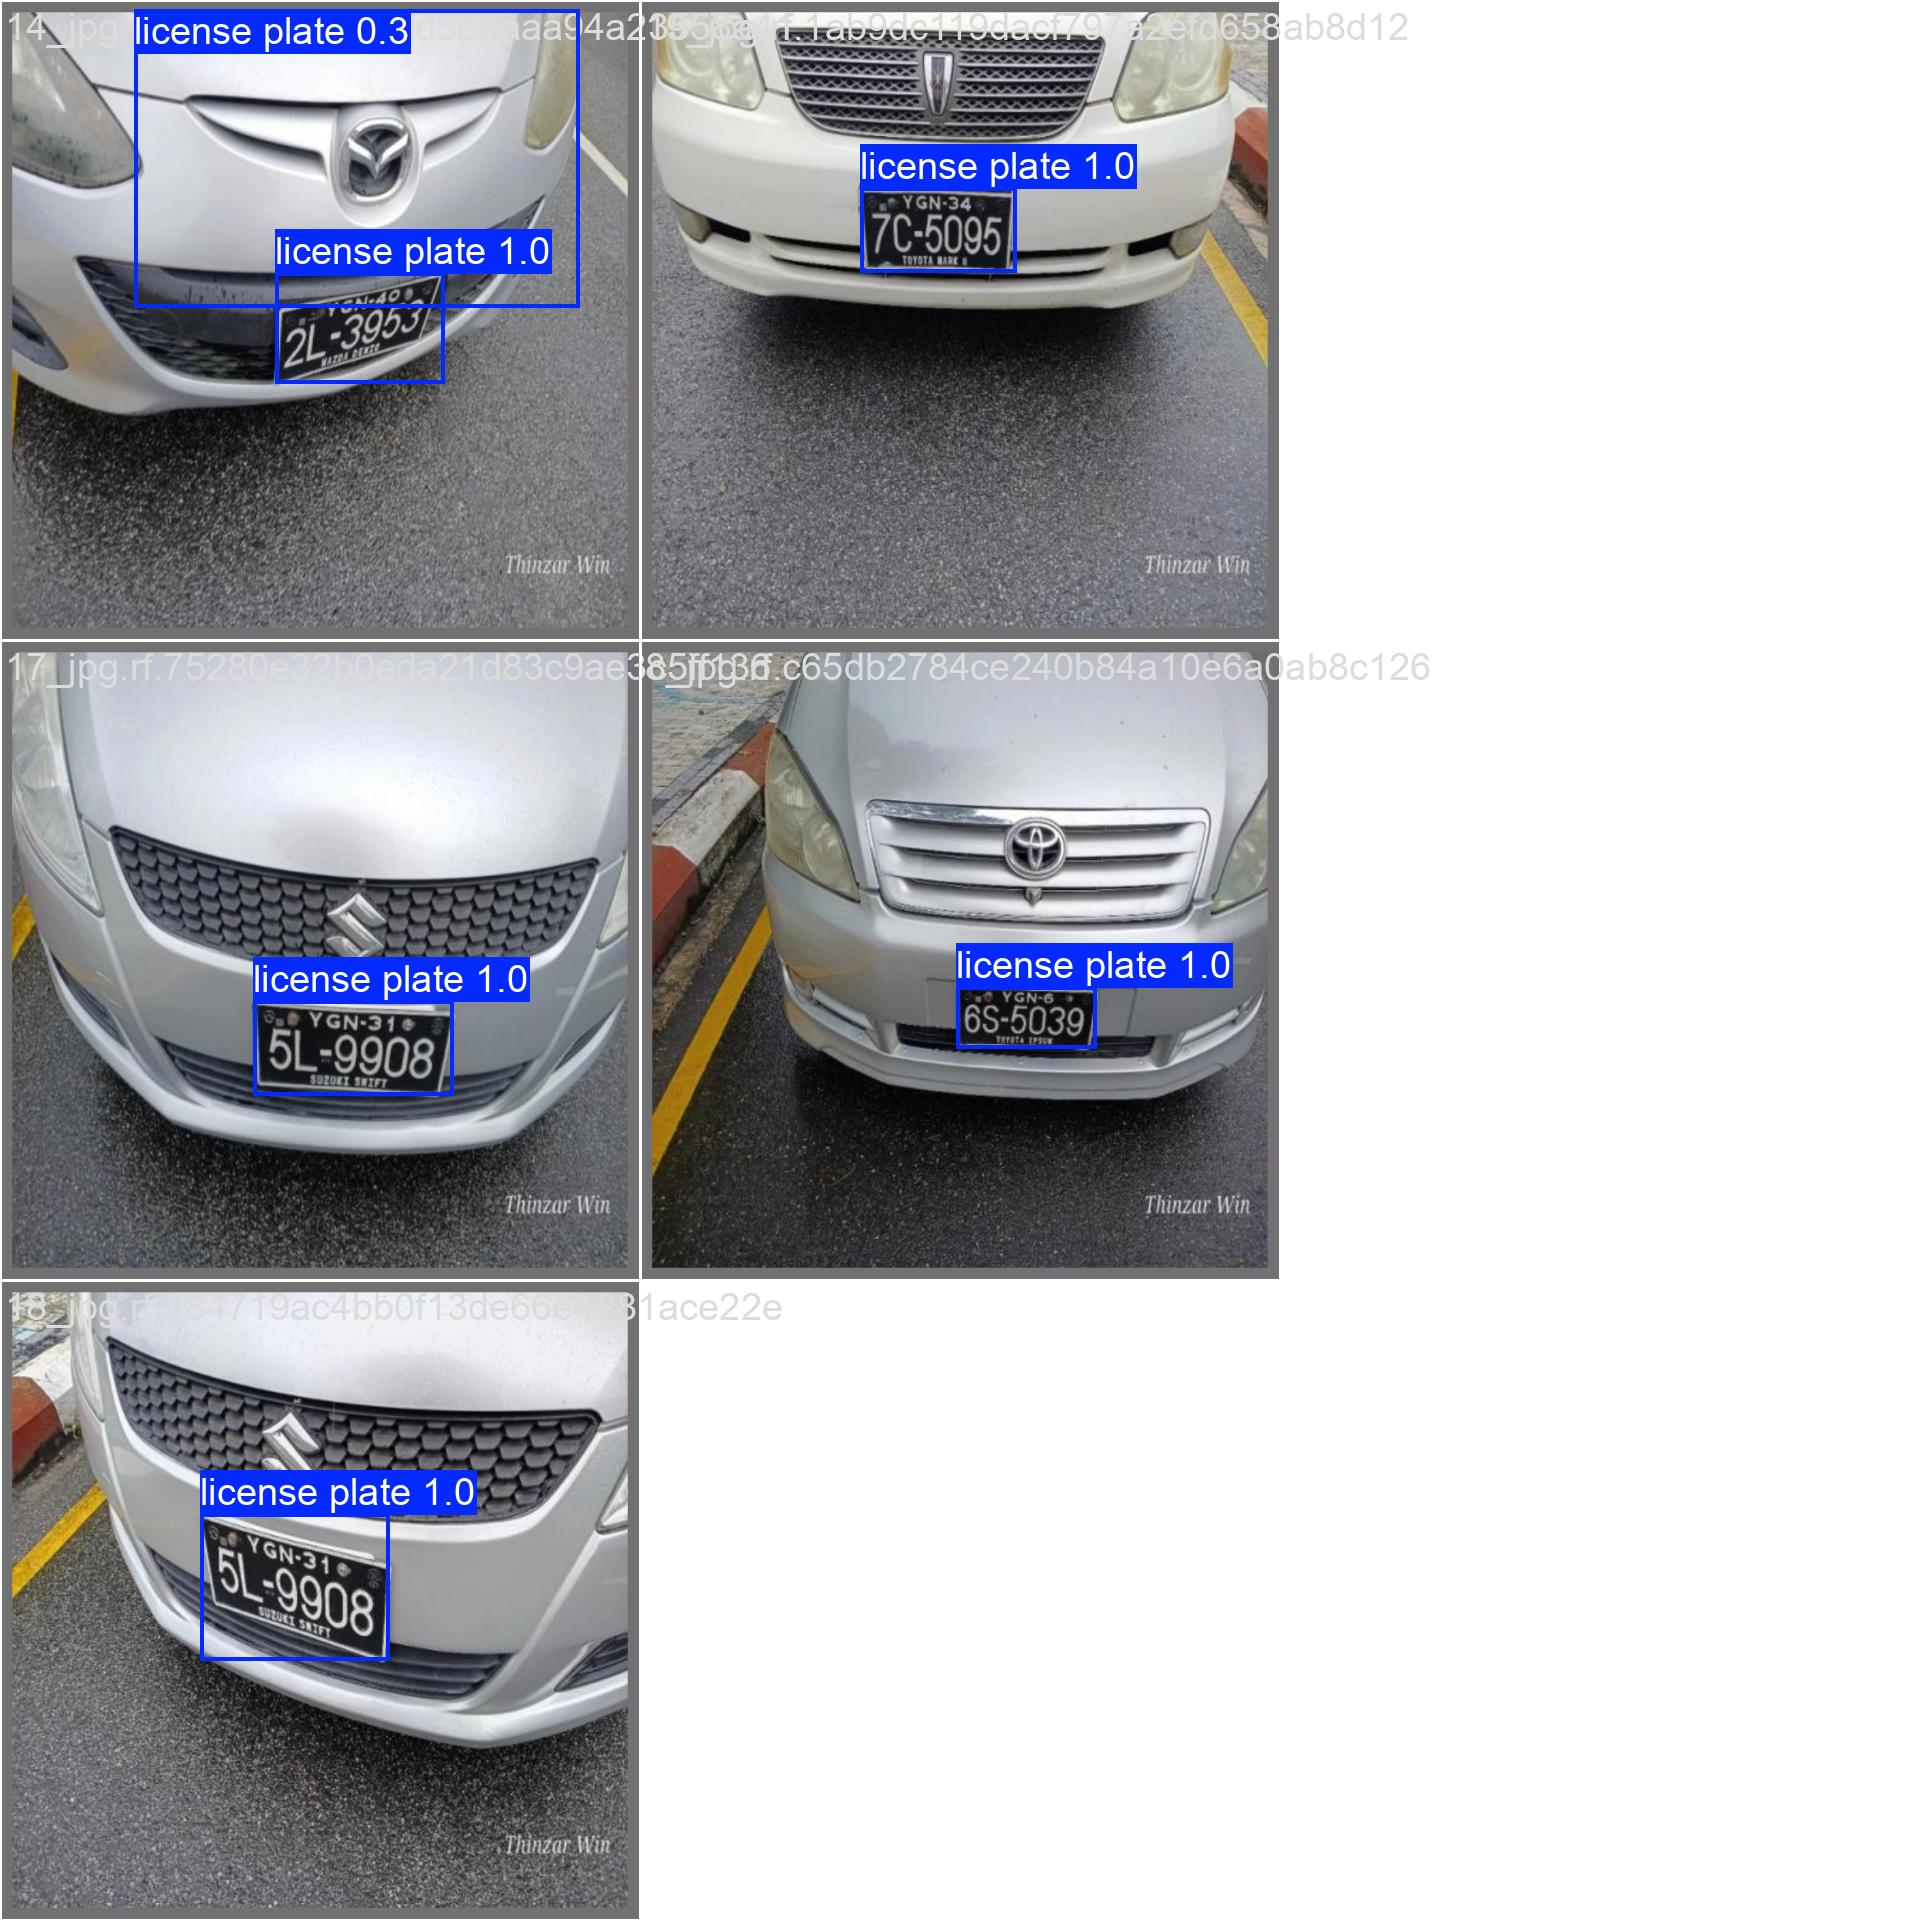

In [24]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [25]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/datasets/License-Plate-Detecction-1/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  3.58it/s]
                   all          5          5      0.989          1      0.995      0.995
Speed: 0.4ms preprocess, 21.9ms inference, 0.0ms loss, 12.4ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with Custom Model

In [26]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/2 /content/datasets/License-Plate-Detecction-1/test/images/22_jpg.rf.9af8c6d33dbbc0a09136d732e2698be5.jpg: 800x800 1 license plate, 22.2ms
image 2/2 /content/datasets/License-Plate-Detecction-1/test/images/5_jpg.rf.a7e821961070a0b8c2b703d2534263d6.jpg: 800x800 2 license plates, 22.2ms
Speed: 5.5ms preprocess, 22.2ms inference, 61.3ms postprocess per image at shape (1, 3, 800, 800)
Results saved to runs/detect/predict3
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Let's take a look at few results.

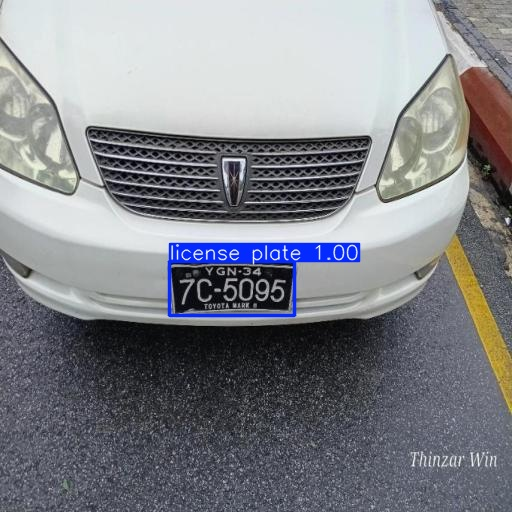

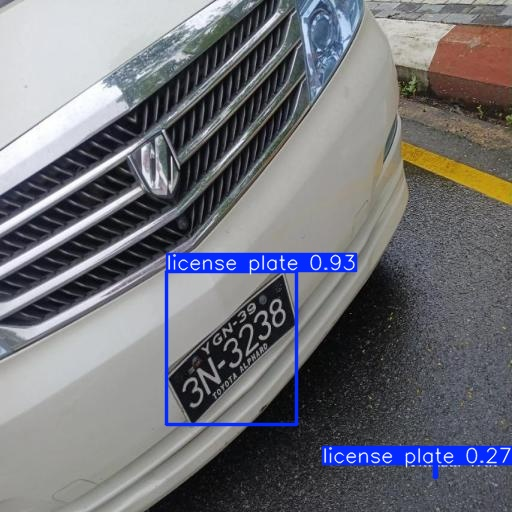

In [27]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv8 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv8 weights.

To upload model weights, add the following code to the “Inference with Custom Model” section in the aforementioned notebook:

In [31]:
project.version(dataset.version).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train/")

Dependency ultralytics==8.0.196 is required but found version=8.2.103, to fix: `pip install ultralytics==8.0.196`
Would you like to continue with the wrong version of ultralytics? y/n: y
An error occured when getting the model upload URL: 401 Client Error: Unauthorized for url: https://api.roboflow.com/ssnowqueen91-gmail-com/license-plate-detecction/1/uploadModel?api_key=y4DNFFE2BjxD7pAt4xy5&modelType=yolov8&nocache=true


In [1]:
import os
import glob
from ultralytics import YOLO
from IPython.display import Image, display

weight_files = glob.glob('runs/detect/train*/weights/best.pt')

if not weight_files:
  print("best.pt is not found")
else:
  best_weight = weight_files[-1]
  print(f"Found weight file:{best_weight}")

model = YOLO(best_weight)

test_folders = glob.glob('**/test/images', recursive=True)
if test_folders:
  test_path =test_folders[0]
  print(f"Testing images path: {test_path}")

  results =model.predict(source=test_path, save=True, conf=0.25)

  predict_folders = sorted(glob.glob('runs/detect/predict*'))
  latest_predict = predict_folders[-1]

  output_images = glob.glob(f'{latest_predict}/*.jpg') + glob.glob(f'{latest_predict}/*.png')
  for img_path in output_images[:3]:
    display(Image(filename=img_path))
else:
  print("Test images folder is not found")

Found weight file:runs/detect/train/weights/best.pt
Testing images path: datasets/License-Plate-Detecction-1/test/images

image 1/2 /content/datasets/License-Plate-Detecction-1/test/images/22_jpg.rf.9af8c6d33dbbc0a09136d732e2698be5.jpg: 800x800 1 license plate, 16.7ms
image 2/2 /content/datasets/License-Plate-Detecction-1/test/images/5_jpg.rf.a7e821961070a0b8c2b703d2534263d6.jpg: 800x800 2 license plates, 16.7ms
Speed: 5.5ms preprocess, 16.7ms inference, 67.8ms postprocess per image at shape (1, 3, 800, 800)
Results saved to runs/detect/predict10
